In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import os
from datetime import datetime

# Add src to path (adjust if needed)
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

# Import our conversion module
from preprocessing.event_to_frame import (
    EventToFrameConverter,
    events_to_frame,
    events_to_frame_sequence,
    normalize_frame
)

In [3]:
plt.style.use('default')
plt.rcParams['figure.figsize'] = (14, 6)

In [4]:
DATA_PATH = Path("C:/Users/Devesh/Downloads/N-MINST")


def load_nmnist_bin(file_path):
    """Load N-MNIST .bin file."""
    with open(file_path, 'rb') as f:
        raw_data = np.fromfile(f, dtype=np.uint8)
    
    n_events = len(raw_data) // 5
    x = np.zeros(n_events, dtype=np.uint16)
    y = np.zeros(n_events, dtype=np.uint16)
    t = np.zeros(n_events, dtype=np.uint32)
    p = np.zeros(n_events, dtype=np.uint8)
    
    for i in range(n_events):
        idx = i * 5
        x[i] = raw_data[idx]
        y[i] = raw_data[idx + 1]
        t_raw = (raw_data[idx + 2] | 
                 (raw_data[idx + 3] << 8) | 
                 (raw_data[idx + 4] << 16))
        p[i] = t_raw & 1
        t[i] = t_raw >> 1
    
    events = np.zeros(n_events, dtype=[
        ('t', np.uint32), ('x', np.uint16),
        ('y', np.uint16), ('p', np.uint8)
    ])
    events['t'], events['x'], events['y'], events['p'] = t, x, y, p
    return events

# Try to load real data
sample_file = None
if DATA_PATH.exists():
    folder_0 = DATA_PATH / "0"
    if folder_0.exists():
        bins = sorted(list(folder_0.glob("*.bin")))
        if len(bins) > 0:
            sample_file = bins[0]

if sample_file and sample_file.exists():
    print(f"📥 Loading: {sample_file.name}")
    events = load_nmnist_bin(sample_file)
    height, width = 34, 34
    print(f"✓ Loaded {len(events):,} events")
else:
    print("⚠️  Creating synthetic data for demonstration...")
    # Create synthetic diagonal motion
    n_events = 2000
    height, width = 34, 34
    events = np.zeros(n_events, dtype=[
        ('t', np.uint32), ('x', np.uint16),
        ('y', np.uint16), ('p', np.uint8)
    ])
    for i in range(n_events):
        events['t'][i] = i * 50  # 50μs apart
        events['x'][i] = int((i / n_events) * (width - 1))
        events['y'][i] = int((i / n_events) * (height - 1))
        events['p'][i] = (i // 10) % 2  # Alternating bursts
    print(f"✓ Created {len(events):,} synthetic events")

print(f"Frame dimensions: {height} x {width}")
print(f"Time span: {events['t'][-1] - events['t'][0]} μs")
print()

📥 Loading: 00002.bin
✓ Loaded 5,028 events
Frame dimensions: 34 x 34
Time span: 2 μs



Output shape: (34, 34)
Value range: [-21.0, 9.0]
Non-zero pixels: 477 / 1156
Positive pixels (ON): 105
Negative pixels (OFF): 372



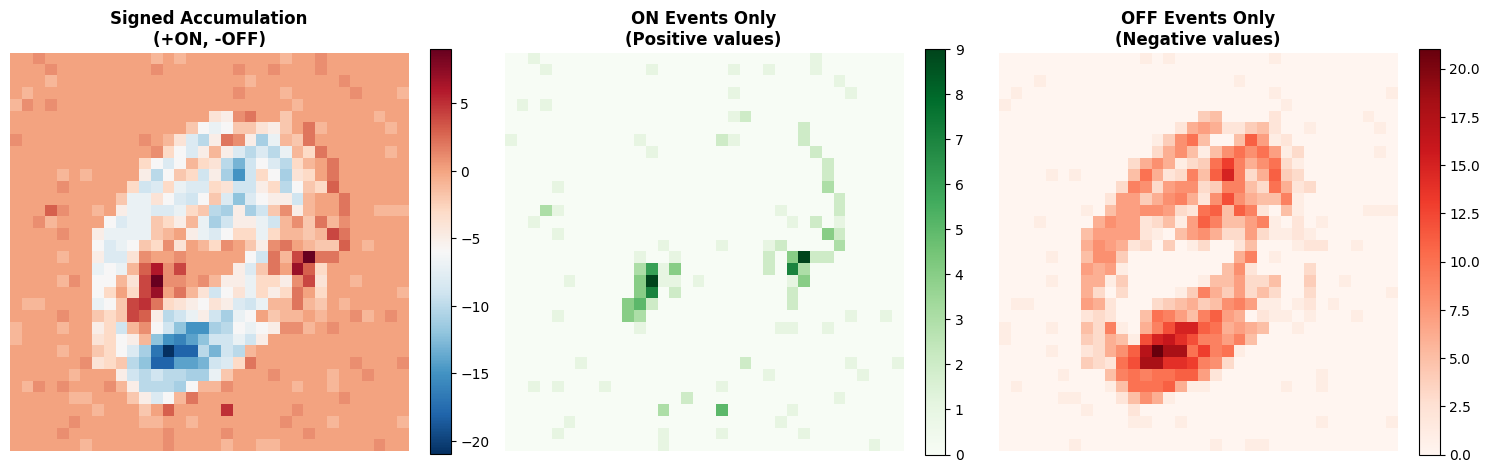

In [6]:
# Create converter
converter = EventToFrameConverter(height, width)

# Convert with signed polarity
frame_signed = converter.events_to_frame(
    events, 
    method='accumulation',
    polarity_mode='signed'
)

print(f"Output shape: {frame_signed.shape}")
print(f"Value range: [{frame_signed.min():.1f}, {frame_signed.max():.1f}]")
print(f"Non-zero pixels: {np.count_nonzero(frame_signed)} / {height * width}")
print(f"Positive pixels (ON): {np.sum(frame_signed > 0)}")
print(f"Negative pixels (OFF): {np.sum(frame_signed < 0)}")
print()

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original accumulation
ax1 = axes[0]
im1 = ax1.imshow(frame_signed, cmap='RdBu_r', interpolation='nearest')
ax1.set_title('Signed Accumulation\n(+ON, -OFF)', fontweight='bold')
ax1.axis('off')
plt.colorbar(im1, ax=ax1, fraction=0.046)

# ON events only
ax2 = axes[1]
frame_on = np.maximum(frame_signed, 0)
im2 = ax2.imshow(frame_on, cmap='Greens', interpolation='nearest')
ax2.set_title('ON Events Only\n(Positive values)', fontweight='bold')
ax2.axis('off')
plt.colorbar(im2, ax=ax2, fraction=0.046)

# OFF events only
ax3 = axes[2]
frame_off = np.abs(np.minimum(frame_signed, 0))
im3 = ax3.imshow(frame_off, cmap='Reds', interpolation='nearest')
ax3.set_title('OFF Events Only\n(Negative values)', fontweight='bold')
ax3.axis('off')
plt.colorbar(im3, ax=ax3, fraction=0.046)

plt.tight_layout()
plt.show()
print()

📊 METHOD 2: EVENT ACCUMULATION (SEPARATE CHANNELS)
Description: Two separate channels for ON and OFF events

Output shape: (34, 34, 2)
ON channel range: [0.0, 13.0]
OFF channel range: [0.0, 22.0]




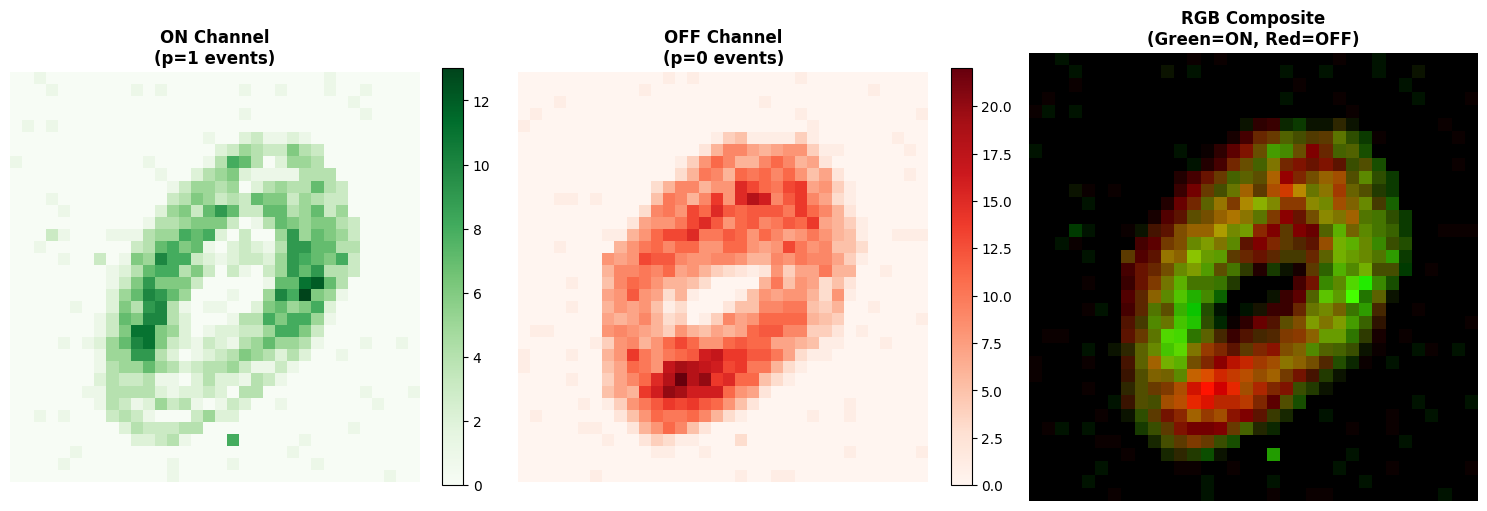

In [7]:
# ## 5. Method 2: Event Accumulation (Separate Channels)

# %%
print("📊 METHOD 2: EVENT ACCUMULATION (SEPARATE CHANNELS)")
print("=" * 70)
print("Description: Two separate channels for ON and OFF events")
print()

# Convert with separate channels
frame_separate = converter.events_to_frame(
    events,
    method='accumulation',
    polarity_mode='separate'
)

print(f"Output shape: {frame_separate.shape}")
print(f"ON channel range: [{frame_separate[..., 0].min():.1f}, {frame_separate[..., 0].max():.1f}]")
print(f"OFF channel range: [{frame_separate[..., 1].min():.1f}, {frame_separate[..., 1].max():.1f}]")
print()

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ON channel
ax1 = axes[0]
im1 = ax1.imshow(frame_separate[..., 0], cmap='Greens', interpolation='nearest')
ax1.set_title('ON Channel\n(p=1 events)', fontweight='bold')
ax1.axis('off')
plt.colorbar(im1, ax=ax1, fraction=0.046)

# OFF channel
ax2 = axes[1]
im2 = ax2.imshow(frame_separate[..., 1], cmap='Reds', interpolation='nearest')
ax2.set_title('OFF Channel\n(p=0 events)', fontweight='bold')
ax2.axis('off')
plt.colorbar(im2, ax=ax2, fraction=0.046)

# RGB composite (for visualization)
ax3 = axes[2]
rgb_frame = np.zeros((height, width, 3))
rgb_frame[..., 1] = normalize_frame(frame_separate[..., 0], 'minmax')  # Green = ON
rgb_frame[..., 0] = normalize_frame(frame_separate[..., 1], 'minmax')  # Red = OFF
im3 = ax3.imshow(rgb_frame, interpolation='nearest')
ax3.set_title('RGB Composite\n(Green=ON, Red=OFF)', fontweight='bold')
ax3.axis('off')

plt.tight_layout()
print()


📊 METHOD 3: TIME SURFACE
Description: Exponential decay from most recent event

Time span: 2 μs
Time window (decay constant): 0.2 μs

Output shape: (34, 34)
Value range: [-1.000, 0.007]



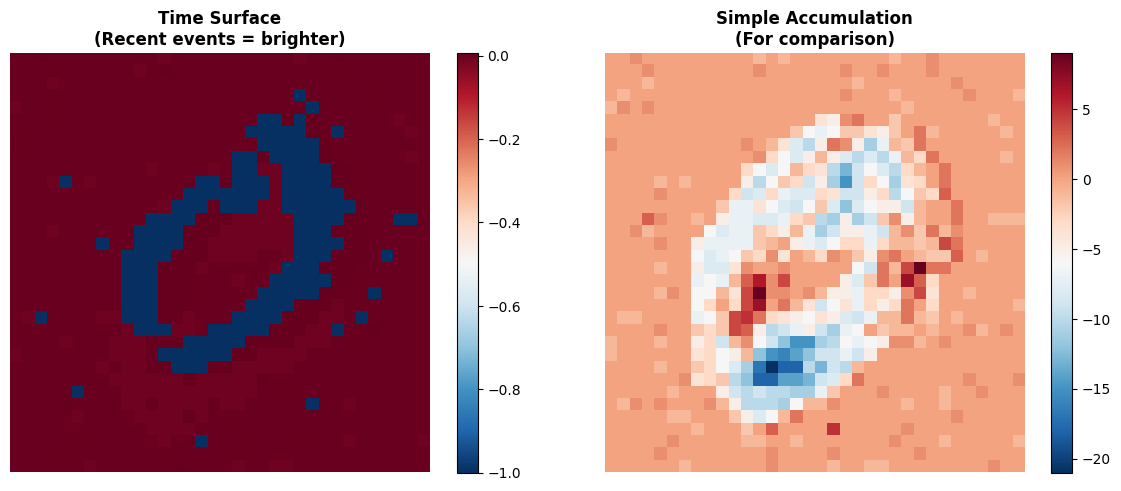

In [8]:
# ## 6. Method 3: Time Surface

# %%
print("📊 METHOD 3: TIME SURFACE")
print("=" * 70)
print("Description: Exponential decay from most recent event")
print()

# Determine appropriate time window
time_span = events['t'][-1] - events['t'][0]
time_window = time_span / 10  # Use 10% of total span

print(f"Time span: {time_span} μs")
print(f"Time window (decay constant): {time_window} μs")
print()

# Convert with time surface
frame_time_surface = converter.events_to_frame(
    events,
    time_window=time_window,
    method='time_surface',
    polarity_mode='signed'
)

print(f"Output shape: {frame_time_surface.shape}")
print(f"Value range: [{frame_time_surface.min():.3f}, {frame_time_surface.max():.3f}]")
print()

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Time surface
ax1 = axes[0]
im1 = ax1.imshow(frame_time_surface, cmap='RdBu_r', interpolation='nearest')
ax1.set_title('Time Surface\n(Recent events = brighter)', fontweight='bold')
ax1.axis('off')
plt.colorbar(im1, ax=ax1, fraction=0.046)

# Simple accumulation for comparison
ax2 = axes[1]
im2 = ax2.imshow(frame_signed, cmap='RdBu_r', interpolation='nearest')
ax2.set_title('Simple Accumulation\n(For comparison)', fontweight='bold')
ax2.axis('off')
plt.colorbar(im2, ax=ax2, fraction=0.046)

plt.tight_layout()
plt.show()
print()

🔍 COMPARING ALL METHODS


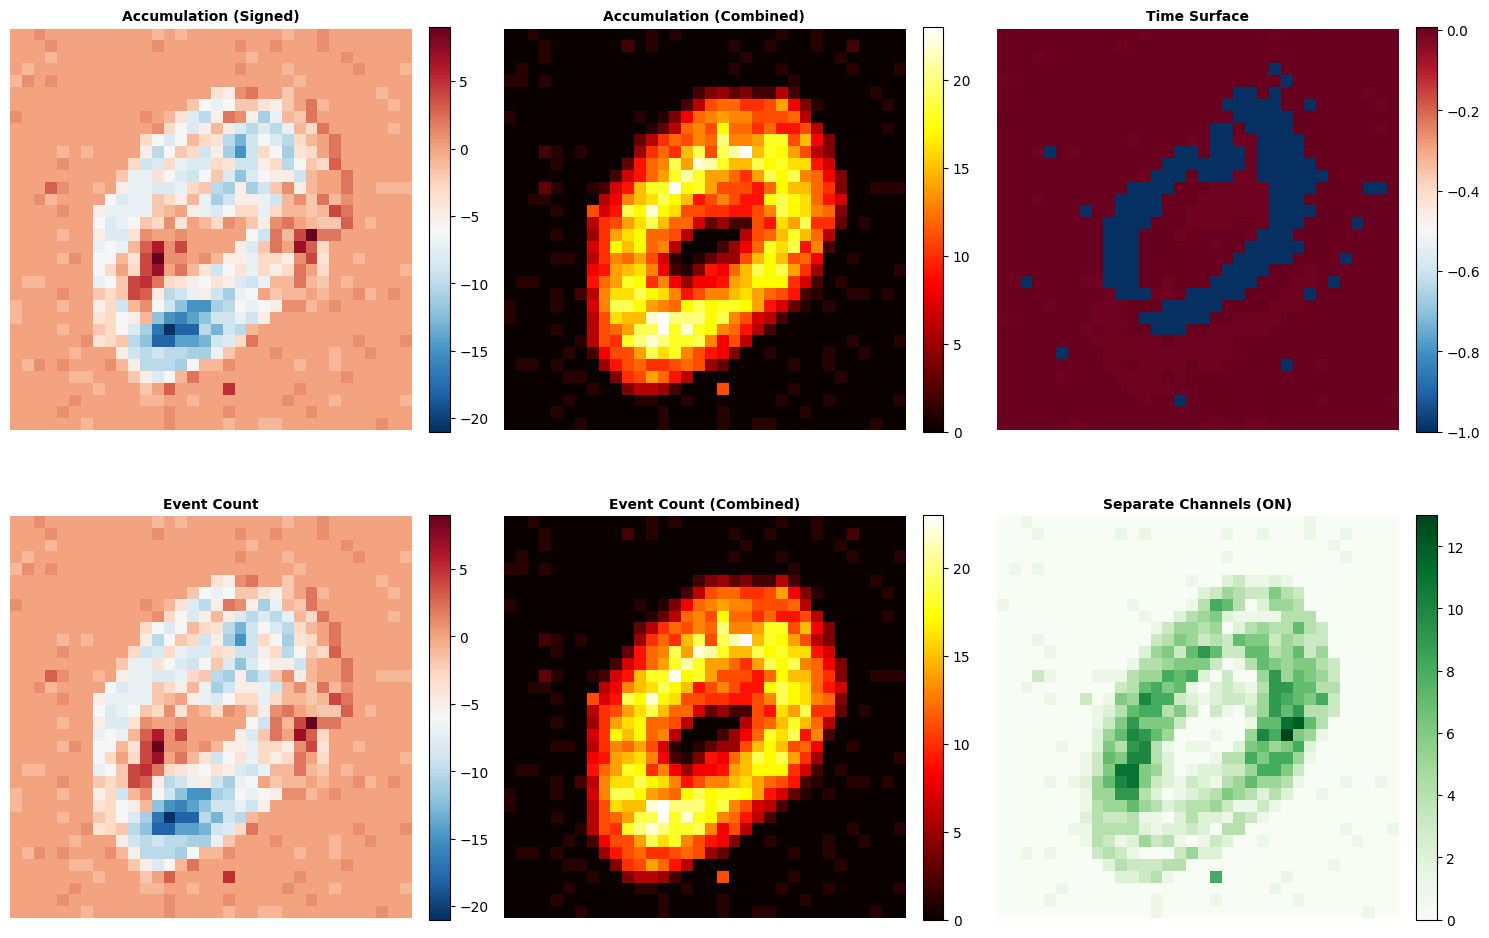

In [9]:
# ## 7. Comparing All Methods Side-by-Side

# %%
print("🔍 COMPARING ALL METHODS")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

methods_info = [
    ('accumulation', 'signed', 'Accumulation (Signed)', 'RdBu_r'),
    ('accumulation', 'combined', 'Accumulation (Combined)', 'hot'),
    ('time_surface', 'signed', 'Time Surface', 'RdBu_r'),
    ('count', 'signed', 'Event Count', 'RdBu_r'),
    ('count', 'combined', 'Event Count (Combined)', 'hot'),
    ('accumulation', 'separate', 'Separate Channels (ON)', 'Greens'),
]

for idx, (method, pol_mode, title, cmap) in enumerate(methods_info):
    ax = axes[idx // 3, idx % 3]
    
    # Convert
    frame = converter.events_to_frame(
        events,
        time_window=time_window if method == 'time_surface' else None,
        method=method,
        polarity_mode=pol_mode
    )
    
    # Handle separate channels case
    if pol_mode == 'separate':
        frame_to_show = frame[..., 0]  # Show ON channel
    else:
        frame_to_show = frame
    
    im = ax.imshow(frame_to_show, cmap=cmap, interpolation='nearest')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
print()


🎬 FRAME SEQUENCE GENERATION
Converting event stream into a sequence of frames...

Generated shape: (8, 34, 34)
Number of frames: 8



C:\Users\Devesh\AppData\Local\Temp\ipykernel_9252\3986627876.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


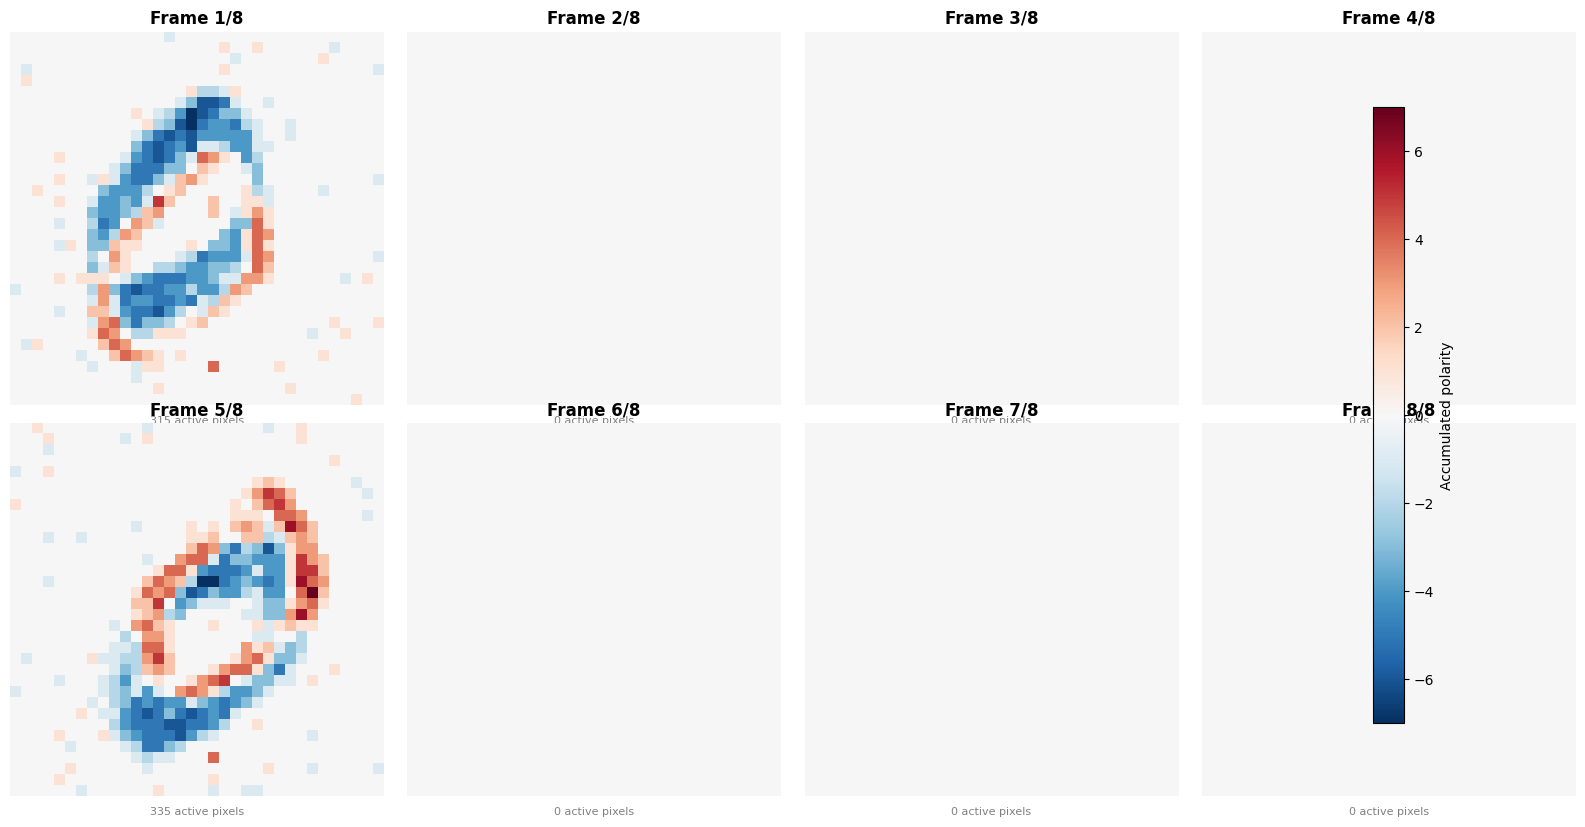

In [10]:
# ## 8. Frame Sequence Generation

# %%
print("🎬 FRAME SEQUENCE GENERATION")
print("=" * 70)
print("Converting event stream into a sequence of frames...")
print()

# Generate sequence
n_frames = 8
frames = converter.events_to_frame_sequence(
    events,
    n_frames=n_frames,
    method='accumulation',
    polarity_mode='signed'
)

print(f"Generated shape: {frames.shape}")
print(f"Number of frames: {n_frames}")
print()

# Visualize sequence
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(n_frames):
    ax = axes[i]
    im = ax.imshow(frames[i], cmap='RdBu_r', interpolation='nearest', 
                   vmin=frames.min(), vmax=frames.max())
    ax.set_title(f'Frame {i+1}/{n_frames}', fontweight='bold')
    ax.axis('off')
    
    # Add event count
    n_evt = np.sum(frames[i] != 0)
    ax.text(0.5, -0.05, f'{n_evt} active pixels', 
            transform=ax.transAxes, ha='center', fontsize=8, color='gray')

plt.colorbar(im, ax=axes, label='Accumulated polarity', fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
print()

⏱️  EFFECT OF TIME WINDOW SIZE
Testing different time windows for frame reconstruction...



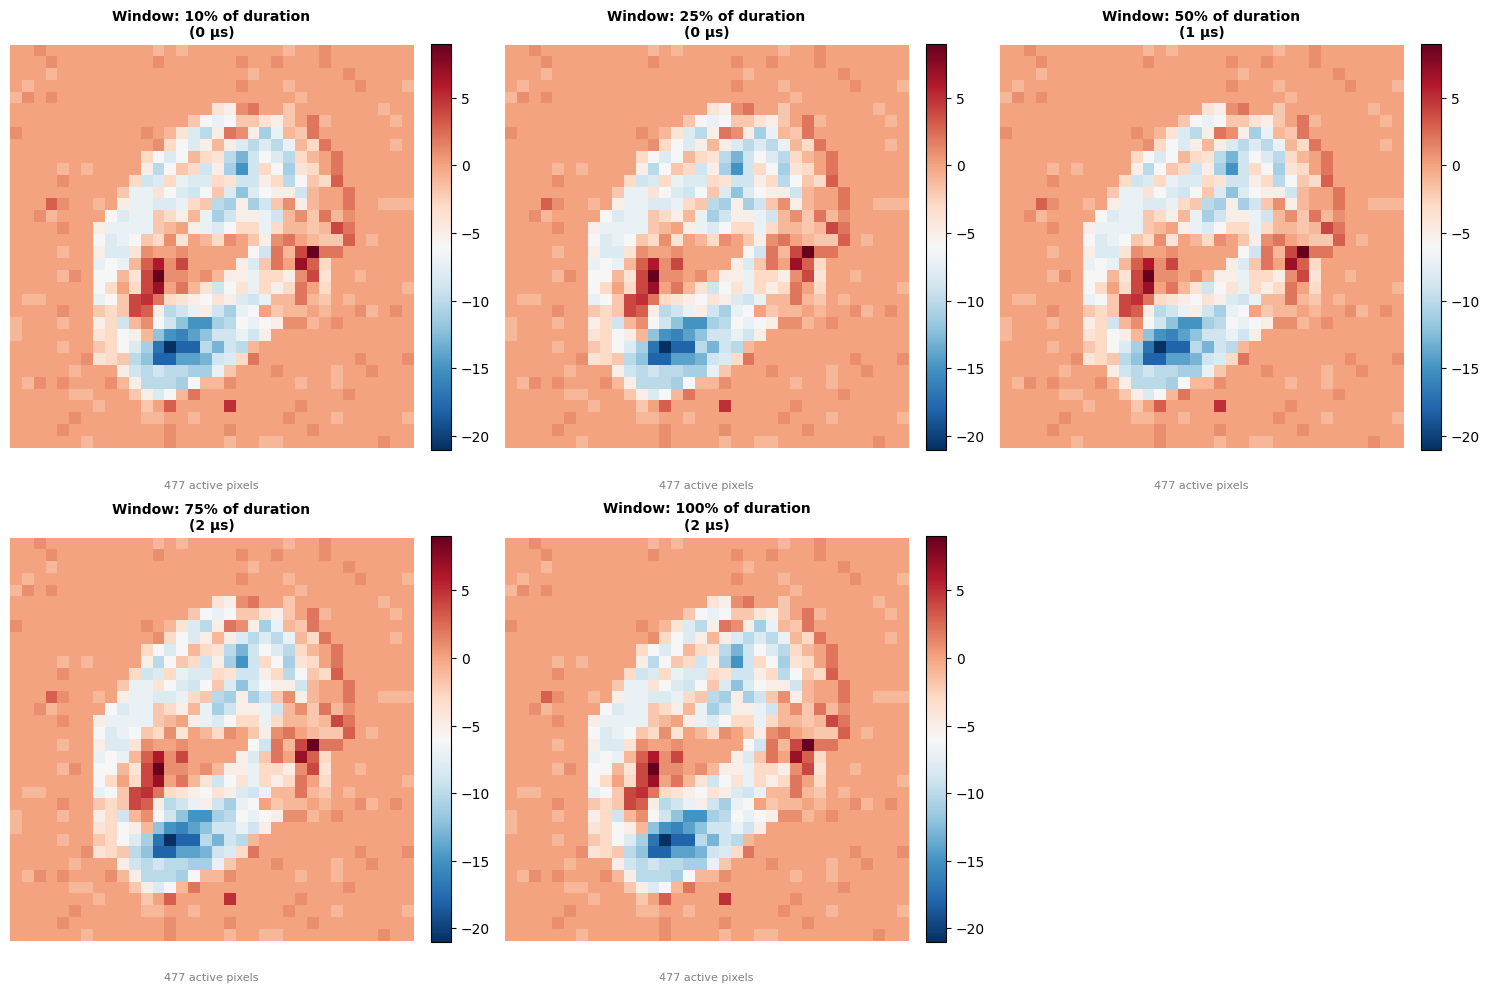

In [11]:
# ## 9. Effect of Time Window Size

# %%
print("⏱️  EFFECT OF TIME WINDOW SIZE")
print("=" * 70)
print("Testing different time windows for frame reconstruction...")
print()

time_windows = [0.1, 0.25, 0.5, 0.75, 1.0]  # Fractions of total duration
total_duration = events['t'][-1] - events['t'][0]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, fraction in enumerate(time_windows):
    if idx >= len(axes):
        break
    
    tw = total_duration * fraction
    frame = converter.events_to_frame(
        events,
        time_window=tw,
        method='accumulation',
        polarity_mode='signed'
    )
    
    ax = axes[idx]
    im = ax.imshow(frame, cmap='RdBu_r', interpolation='nearest')
    ax.set_title(f'Window: {fraction*100:.0f}% of duration\n({tw:.0f} μs)', 
                 fontweight='bold', fontsize=10)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    # Stats
    n_active = np.count_nonzero(frame)
    ax.text(0.5, -0.1, f'{n_active} active pixels', 
            transform=ax.transAxes, ha='center', fontsize=8, color='gray')

# Hide extra subplot
if len(time_windows) < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.show()
print()

🎨 NORMALIZATION TECHNIQUES


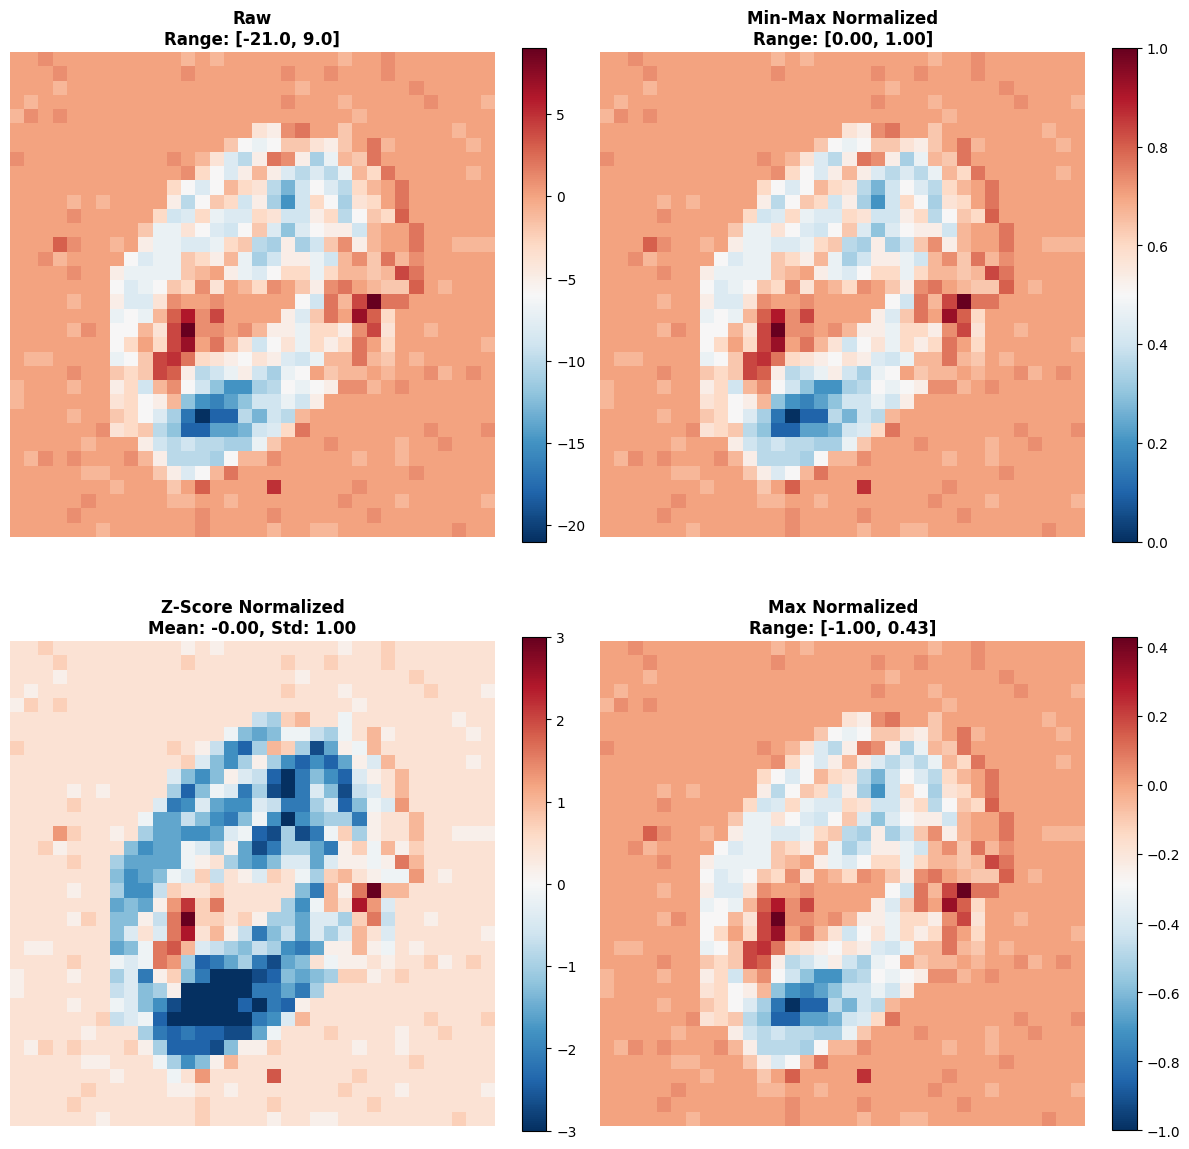

In [12]:
# ## 10. Normalization Techniques

# %%
print("🎨 NORMALIZATION TECHNIQUES")
print("=" * 70)

# Get a frame with accumulation
frame_raw = converter.events_to_frame(
    events,
    method='accumulation',
    polarity_mode='signed'
)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Original (raw)
ax1 = axes[0, 0]
im1 = ax1.imshow(frame_raw, cmap='RdBu_r', interpolation='nearest')
ax1.set_title(f'Raw\nRange: [{frame_raw.min():.1f}, {frame_raw.max():.1f}]', 
              fontweight='bold')
ax1.axis('off')
plt.colorbar(im1, ax=ax1, fraction=0.046)

# Min-Max normalization
ax2 = axes[0, 1]
frame_minmax = normalize_frame(frame_raw, method='minmax')
im2 = ax2.imshow(frame_minmax, cmap='RdBu_r', interpolation='nearest')
ax2.set_title(f'Min-Max Normalized\nRange: [{frame_minmax.min():.2f}, {frame_minmax.max():.2f}]',
              fontweight='bold')
ax2.axis('off')
plt.colorbar(im2, ax=ax2, fraction=0.046)

# Z-score normalization
ax3 = axes[1, 0]
frame_zscore = normalize_frame(frame_raw, method='zscore')
im3 = ax3.imshow(frame_zscore, cmap='RdBu_r', interpolation='nearest', 
                 vmin=-3, vmax=3)
ax3.set_title(f'Z-Score Normalized\nMean: {frame_zscore.mean():.2f}, Std: {frame_zscore.std():.2f}',
              fontweight='bold')
ax3.axis('off')
plt.colorbar(im3, ax=ax3, fraction=0.046)

# Max normalization
ax4 = axes[1, 1]
frame_max = normalize_frame(frame_raw, method='max')
im4 = ax4.imshow(frame_max, cmap='RdBu_r', interpolation='nearest')
ax4.set_title(f'Max Normalized\nRange: [{frame_max.min():.2f}, {frame_max.max():.2f}]',
              fontweight='bold')
ax4.axis('off')
plt.colorbar(im4, ax=ax4, fraction=0.046)

plt.tight_layout()
plt.show()
print()